In [138]:
import pandas as pd
import numpy as np
from astropy.timeseries import LombScargle
import scipy.signal as signal
import random
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath("../astro_tool"))
print(sys.path)
import astro_tool.scripts.base as base
from scipy.fft import fft, ifft
import astro_tool.scripts.evaluate as evaluate


['/Users/amon/Documents/Apps/Python/astro_tool/notebooks', '/opt/anaconda3/envs/astro_tool/lib/python312.zip', '/opt/anaconda3/envs/astro_tool/lib/python3.12', '/opt/anaconda3/envs/astro_tool/lib/python3.12/lib-dynload', '', '/opt/anaconda3/envs/astro_tool/lib/python3.12/site-packages', '/Users/amon/Documents/Apps/Python/astro_tool', '/Users/amon/Documents/Apps/Python/astro_tool/astro_tool', '/Users/amon/Documents/Apps/Python/astro_tool/astro_tool', '/Users/amon/Documents/Apps/Python/astro_tool/astro_tool', '/Users/amon/Documents/Apps/Python/astro_tool/astro_tool', '/Users/amon/Documents/Apps/Python/astro_tool/astro_tool', '/Users/amon/Documents/Apps/Python/astro_tool/astro_tool', '/Users/amon/Documents/Apps/Python/astro_tool/astro_tool', '/Users/amon/Documents/Apps/Python/astro_tool/astro_tool', '/Users/amon/Documents/Apps/Python/astro_tool/astro_tool', '/Users/amon/Documents/Apps/Python/astro_tool/astro_tool', '/Users/amon/Documents/Apps/Python/astro_tool/astro_tool', '/Users/amon/Do

In [139]:
data = base.load_processed_data()

In [140]:
def move(t):
    temp = 0
    for i in range(len(t)):
        if t[i] - 50 > temp:
            return t - t[i-1]
        else:
            temp = t[i]
    return t 

def fourier(t):
    # Lomb-Scargle Periodogram
    min_t = 20 # min detectation window in days
    max_t = 2*max(t) # max detectation window in days
    frequency, power = LombScargle(t, np.ones_like(t)).autopower(minimum_frequency = 1/max_t, maximum_frequency = 1/min_t, samples_per_peak=10)
    fourier = pd.DataFrame({"frequency":frequency,"power":power})
    fourier = fourier[(fourier["frequency"] < 1/min_t) & (fourier["frequency"] > 1/max_t)]

    return fourier

In [141]:
t = []
f = pd.DataFrame()
for val in data:
    temp = val.data["JD"].values
    if len(temp) < 10:
        continue
    temp = temp - np.min(temp)
    temp_f = fourier(temp)
    
    f = pd.concat([f, temp_f])

    temp = move(temp)
    t.append(temp)
t = np.concatenate(t)
f.sort_values(by="frequency", ascending=False, inplace=True)
f.reset_index(inplace=True)
print(f"F:\n{f}")

/opt/anaconda3/envs/astro_tool/lib/python3.12/site-packages/astropy/timeseries/periodograms/lombscargle/implementations/fast_impl.py:134: RuntimeWarning: invalid value encountered in divide
  power /= YY


F:
        index  frequency     power
0         326   0.010000  0.000047
1         318   0.010000  0.000539
2         348   0.010000  0.003624
3         337   0.010000  0.011720
4         343   0.010000  0.002092
...       ...        ...       ...
540007      1   0.002021  0.006686
540008      1   0.002021  0.000992
540009      1   0.002021  0.000243
540010      1   0.002021  0.010922
540011      1   0.002021  0.000378

[540012 rows x 3 columns]


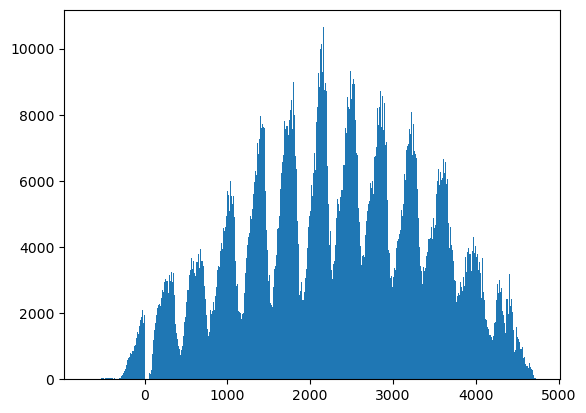

In [142]:
plt.hist(t,bins=500)
plt.show()

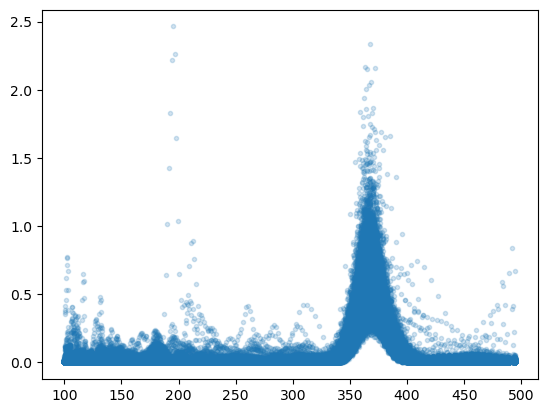

In [143]:
plt.scatter(1/f["frequency"],f["power"],alpha = 0.2, marker='.')
plt.show()